In [1]:
## Produce the smearing matrices & efficiencies using the intrinsic nue samples

## Setup

In [2]:
import sys
sys.path.insert(0, 'backend_functions')
from scipy.stats import norm
from matplotlib.colors import LogNorm
import xsec_functions

import importlib
import uproot
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

importlib.reload(xsec_functions)
from xsec_functions import *

import selection_functions
import awkward

import ROOT

from ROOT import TH2D, TH1D, TH1F

import top 
from top import *

# This is our configuration file, cfg.py, which contains the variable names and related info.
import cfg
from cfg import *

Welcome to JupyROOT 6.28/00


In [3]:
importlib.reload(selection_functions)
from selection_functions import *

In [4]:
importlib.reload(xsec_functions)
from xsec_functions import *

In [5]:
# No special instructions for closure test or NuWro here 

# Choose your run! 
ISRUN3 = True # True for Run 3 | False for Run 1

cut_level = ""

In [6]:
# Choose your variable!
# Variables = "Opening Angle", "Proton Multiplicity", "Electron Energy", "Visible Energy"
name_of_variable = "X" 
xvar, true_var, bins, xlow, xhigh, x_label, x_ticks = get_variable_info(name_of_variable, ISRUN3, cut_level)

From cfg.py...
Variable definition: X
Reconstructed variable = tksh_angle
True variable = opening_angle
Bins = [-1.0, 1.0]
Lowest x-value on plot = -1.0
Highest x-value on plot = 1.0
x-axis title = Total Cross Section
x-axis labels = [-1.0, 1.0]


In [7]:
fold = "nuselection"
tree = "NeutrinoSelectionFilter"

# slimmed with opening angle 
#path = parameters(ISRUN3)['cv_ntuple_path']
path = parameters(ISRUN3)['full_ntuple_path'] # Pretty sure this is the correct one... 
print('path = ', path)

#NUE = parameters(ISRUN3)['NUE']

#if not ISRUN3: 
    
    #NUE = 'neutrinoselection_filt_run1_overlay_intrinsic_v7'

#else: 
    
    #NUE = 'neutrinoselection_filt_run3b_overlay_intrinsic_v7'

path =  /Users/abarnard/phd/pelee_ntuples/run3b/unslimmed/


In [8]:
# The unslimmed files need to be used here! 
if ISRUN3:
    nue = uproot.open("/Users/abarnard/phd/pelee_ntuples/run3b/unslimmed/numi_nue_run3.root")[fold][tree]

else:
    nue = uproot.open("/Users/abarnard/phd/pelee_ntuples/run1/unslimmed/numi_nue_run1.root")[fold][tree]

uproot_nue = nue

## Create pandas dataframes

In [9]:

variables = [
    "selected", "nu_pdg", 
    "trk_score_v", 
    "shr_tkfit_dedx_Y",
    "ccnc", 
    "n_tracks_contained", 
    "NeutrinoEnergy2",
    "reco_nu_vtx_sce_x","reco_nu_vtx_sce_y","reco_nu_vtx_sce_z",
    "true_nu_vtx_x", "true_nu_vtx_y" , "true_nu_vtx_z", 
    "nproton", "nu_e", "n_showers_contained",
    "shr_score", 
    "trk_energy", "tksh_distance", "tksh_angle",
    "npi0", 
    "shr_energy_tot_cali", "shr_energy_cali", 
    "nslice",
    "contained_fraction",
    "npion", 
    "shrmoliereavg", 
    "shrsubclusters0","shrsubclusters1","shrsubclusters2", 
    "shr_tkfit_npointsvalid","shr_tkfit_npoints", "true_e_visible", "trkshrhitdist2", 
    "weightSplineTimesTune", "weightTune", "true_nu_px", "true_nu_py", "true_nu_pz", 
    "elec_e", "proton_e", "mc_px", "mc_py", "mc_pz", "elec_px", "elec_py", "elec_pz", 
    "swtrig_pre", "ppfx_cv", "mc_pdg", 'opening_angle', 'interaction', 'run', 'nelec']


In [10]:
nue = nue.pandas.df(variables, flatten=False)

In [11]:
# corrected visible energy variable - account for electrons below 30 MeV 
# use this variable for the visible energy unfolding 

visible_energy_nothres(nue)

In [12]:
# Not adding the angles as now using slimmed files
#nue = addAngles(nue)

trk_llr_pid_v = uproot_nue.array('trk_llr_pid_score_v')
trk_id = uproot_nue.array('trk_id')-1 # I think we need this -1 to get the right result
trk_llr_pid_v_sel = awkward.fromiter([pidv[tid] if tid<len(pidv) else 9999. for pidv,tid in zip(trk_llr_pid_v,trk_id)])

nue['trkpid'] = trk_llr_pid_v_sel
nue['subcluster'] = nue['shrsubclusters0'] + nue['shrsubclusters1'] + nue['shrsubclusters2']
nue['trkfit'] = nue['shr_tkfit_npointsvalid'] / nue['shr_tkfit_npoints']
    
nue['NeutrinoEnergy2_GeV'] = nue['NeutrinoEnergy2']/1000

# Correction for reconstructed electron energy 
nue['shr_energy_cali'] = nue['shr_energy_cali']/0.83


# nue['is_signal'] = np.where((nue.swtrig_pre == 1) &
#                                (nue.nu_pdg==12) & (nue.ccnc==0) & (nue.nproton>0) & (nue.npion==0) & (nue.npi0==0)
#                              & (10 <= nue.true_nu_vtx_x) & (nue.true_nu_vtx_x <= 246)
#                              & (-106 <= nue.true_nu_vtx_y) & (nue.true_nu_vtx_y <= 106)
#                              & (10 <= nue.true_nu_vtx_z) & (nue.true_nu_vtx_z <= 1026), True, False)

# Removed the software trigger requirement because this shouldn't be in the signal deifnition
nue['is_signal'] = np.where((nue.nu_pdg==12) & (nue.ccnc==0) & (nue.nproton>0) & (nue.npion==0) & (nue.npi0==0)
                             & (10 <= nue.true_nu_vtx_x) & (nue.true_nu_vtx_x <= 246)
                             & (-106 <= nue.true_nu_vtx_y) & (nue.true_nu_vtx_y <= 106)
                             & (10 <= nue.true_nu_vtx_z) & (nue.true_nu_vtx_z <= 1026), True, False)

In [13]:
# Don't think we need this anymore?
# nue = nue.query('swtrig_pre==1')

## Weights

In [14]:
# cuts applied for bad weights 

# Added the ppfx_cv cuts here - 30 is the baseline! 
nue.loc[ nue['ppfx_cv'] <= 0, 'ppfx_cv' ] = 1.
nue.loc[ nue['ppfx_cv'] == np.inf, 'ppfx_cv' ] = 1.
nue.loc[ nue['ppfx_cv'] > 30, 'ppfx_cv' ] = 1.
nue.loc[ np.isnan(nue['ppfx_cv']) == True, 'ppfx_cv' ] = 1.

nue.loc[ nue['weightSplineTimesTune'] <= 0, 'weightSplineTimesTune' ] = 1.
nue.loc[ nue['weightSplineTimesTune'] == np.inf, 'weightSplineTimesTune' ] = 1.
nue.loc[ nue['weightSplineTimesTune'] > 30, 'weightSplineTimesTune' ] = 1.
nue.loc[ np.isnan(nue['weightSplineTimesTune']) == True, 'weightSplineTimesTune' ] = 1.
    
nue.loc[ nue['weightTune'] <= 0, 'weightTune' ] = 1.
nue.loc[ nue['weightTune'] == np.inf, 'weightTune' ] = 1.
nue.loc[ nue['weightTune'] > 30, 'weightTune' ] = 1.
nue.loc[ np.isnan(nue['weightTune']) == True, 'weightTune' ] = 1.  

In [15]:
nue = pot_scale(nue, 'intrinsic', ISRUN3)

Adding pot_scale column using dirt & EXT tune....


In [16]:
# WEIGHTS TO POTENTIALLY CHANGE
# total weight - combined genie * flux weight (POT scale to intrinsic overlay)
nue['totweight_intrinsic'] = nue['ppfx_cv']*nue['weightSplineTimesTune']
nue['totweight_data'] = nue['ppfx_cv']*nue['weightSplineTimesTune']*nue['pot_scale']

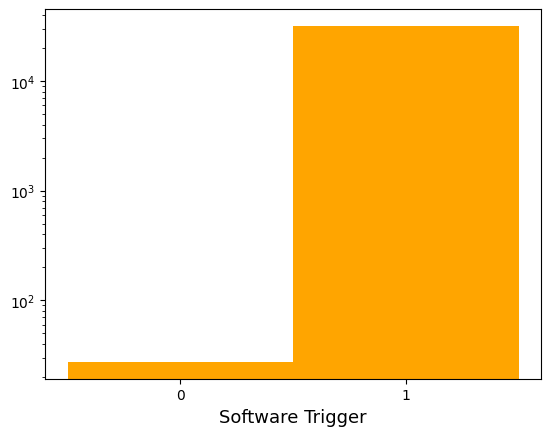

Signal passing SW trigger =  31798.208984375
Signal failing SW trigger =  27.421764373779297


In [17]:
# software trigger distribution 
# This is just plotting - no need to remove

n = plt.hist(nue.query('is_signal==True').swtrig_pre, bins=[-0.5, 0.5, 1.5], color='orange', 
         weights=nue.query('is_signal==True')['totweight_intrinsic'])[0]

plt.xlabel("Software Trigger", fontsize=13)
plt.xticks([0,1])
plt.yscale("log")
plt.show()

print('Signal passing SW trigger = ', n[1])
print('Signal failing SW trigger = ', n[0])


In [18]:
# all we care about is signal 
signal_df = nue.query('is_signal==True')

In [19]:
ISRUN3

True

## Interaction Breakdown

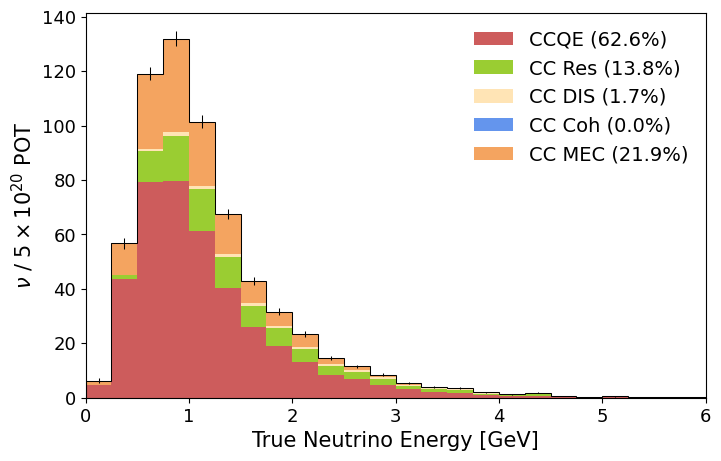

In [20]:
int_labels = {
    '0': 'CCQE', 
    '1': 'CC Res', 
    '2': 'CC DIS', 
    '3': 'CC Coh', 
    '10': 'CC MEC' 
}

fig = plt.figure(figsize=(8, 5))

xvar = 'nu_e'

ccqe = signal_df.query('interaction==0')
ccres = signal_df.query('interaction==1')
ccdis = signal_df.query('interaction==2')
cccoh = signal_df.query('interaction==3')
ccmec = signal_df.query('interaction==10')

int_weights = [ccqe['totweight_data'], 
                 ccres['totweight_data'], 
                 ccdis['totweight_data'], 
                 cccoh['totweight_data'], 
                 ccmec['totweight_data']]

int_counts = []
for l in int_weights: 
    int_counts.append( np.nansum(l) )
    
tot_count = sum(int_counts)
int_counts = [str(round((x/tot_count)*100, 1)) for x in int_counts]

# signal broken down by interactions after the selection 
n, b, p = plt.hist([ccqe[xvar], ccres[xvar], ccdis[xvar], cccoh[xvar], ccmec[xvar]],
          [x*0.25 for x in range(25)], 
          weights=int_weights,
          label=[int_labels['0']+' ('+int_counts[0]+'%)', 
                 int_labels['1']+' ('+int_counts[1]+'%)', 
                 int_labels['2']+' ('+int_counts[2]+'%)', 
                 int_labels['3']+' ('+int_counts[3]+'%)', 
                 int_labels['10']+' ('+int_counts[4]+'%)'],
          color=[ 'indianred','yellowgreen','moccasin',  'cornflowerblue', 'sandybrown'], 
          stacked=True)

bincenters = 0.5*(b[1:]+b[:-1])

y_err = mc_error(xvar, b, b[0], b[-1], [signal_df])
#y_err = [x*y for x, y in zip(n[-1], signal_percent_err)]

plt.hist(bincenters, b, color='black', linewidth=0.75, weights=n[-1], histtype='step')
plt.errorbar(bincenters, n[-1], yerr=y_err,
             color='black', linewidth=.75, fmt='none')#, alpha=.7)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.xlabel("True Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('$\\nu$ / $5\\times10^{20}$ POT', fontsize=15)
#plt.title('RHC RUN 3 Event Rate', fontsize=16)

plt.legend(frameon=False, fontsize=14)

plt.xlim(0, 6)

#plt.savefig(parameters(ISRUN3)['plots_path']+"RHCInteractions.pdf", transparent=True, bbox_inches='tight') 

plt.show()

## Apply BDT selection

In [21]:
bdt_score_cut = parameters(ISRUN3)['bdt_score_cut']
print("BDT SCORE THRESHOLD = "+str(bdt_score_cut))

BDT SCORE THRESHOLD = 0.575


In [22]:
selected_signal_query = 'is_signal==True and '+BDT_LOOSE_CUTS+' and BDT_score>'+str(bdt_score_cut)

In [23]:
bdt_model = xgb.Booster({'nthread': 4})
bdt_model.load_model(parameters(ISRUN3)['bdt_model'])


/Users/abarnard/miniforge3/envs/ccnpenv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:55:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:1070: Loading model from XGBoost < 1.0.0, consider saving it again for improved compatibility
  warnings.warn(smsg, UserWarning)


In [24]:
# pandas data frame which contains the data after the main cuts are applied.
signal_df = signal_df.query(BDT_LOOSE_CUTS+' and is_signal==True')

# clean datasets 
for column in training_parameters:
    signal_df.loc[(signal_df[column] < -1.0e37) | (signal_df[column] > 1.0e37), column] = np.nan
    
# create testing dmatrix 
signal_test = xgb.DMatrix(data=signal_df[training_parameters])
    
# apply the bdt selection
preds = bdt_model.predict(signal_test)

# add columns for plotting 
signal_df['BDT_score'] = preds

print('Number of selected signal events = ' + str(sum(signal_df.query(selected_signal_query).totweight_intrinsic)))

Number of selected signal events = 3907.8389785674917


In [25]:
ISRUN3

True

In [26]:
parameters(ISRUN3)['plots_path']

'/Users/abarnard/phd/ccnp/uBNuMI_CC1eNp/plots/rhc/'

## Electron energy correction probing

### Double plot of true vs. reconstructed electron energy 

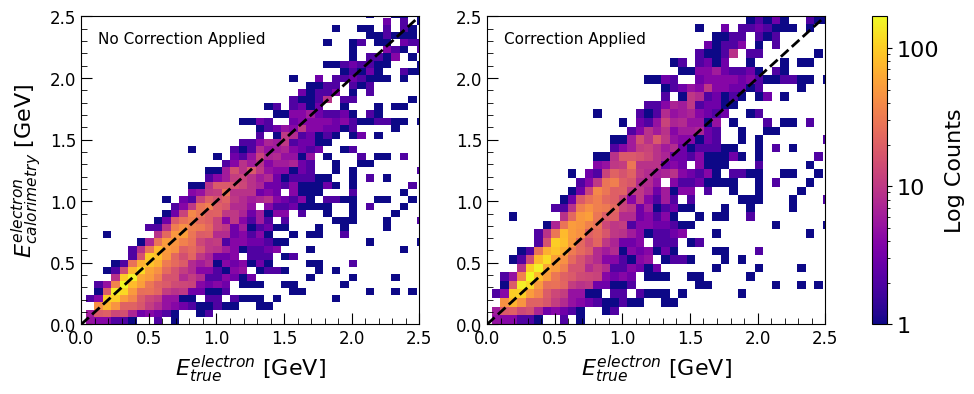

In [27]:
# Extra requirements for the log graph and such 
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter, StrMethodFormatter

# Define the range for the x and y-axes
x_min = 0
x_max = 2.5
y_min = 0
y_max = 2.5

# Define the number of bins for the histogram
x_bins = 100  
y_bins = 100

# Create subplots with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plotting the 2D histograms with a logarithmic scale
axs[0].hist2d(signal_df['elec_e'], signal_df['shr_energy_cali'], bins=(x_bins, y_bins), cmap='plasma', norm=LogNorm()) # No correction
axs[1].hist2d(signal_df['elec_e'], signal_df['shr_energy_cali']/0.83, bins=(x_bins, y_bins), cmap='plasma', norm=LogNorm()) # Correction

# Colorbar
cbar = fig.colorbar(axs[1].collections[0], ax=axs, label='Log Counts', format=StrMethodFormatter('{x:.0f}'))
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Log Counts', fontsize=16) 

# Set x and y axis labels and limits
for ax in axs:
    ax.set_xlabel(r'$E^{electron}_{true}$ [GeV]', fontsize=16)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.minorticks_on()
    ax.tick_params(direction='in', which='both')
    ax.tick_params(axis='both', which='major', length=8)
    ax.tick_params(axis='both', which='minor', length=4)
    ax.tick_params(axis='both', labelsize=12)
    # Plotting the line of y = x for both plots. 
    ax.plot([x_min, x_max], [y_min, y_max], color='black', linestyle='--', linewidth=2)

# Add y-label only to the first subplot
axs[0].set_ylabel(r'$E^{electron}_{calorimetry}$ [GeV]', fontsize=16)

# Add text labels
axs[0].text(0.05, 0.95, 'No Correction Applied', fontsize=11, ha='left', va='top', transform=axs[0].transAxes)
axs[1].text(0.05, 0.95, 'Correction Applied', fontsize=11, ha='left', va='top', transform=axs[1].transAxes)

# Save the figure to my area
# plt.savefig('/exp/uboone/app/users/abarnard/Reco_vs_True_Elec_Energy.pdf', bbox_inches='tight')

plt.show()

### Double plot relative energy resolution

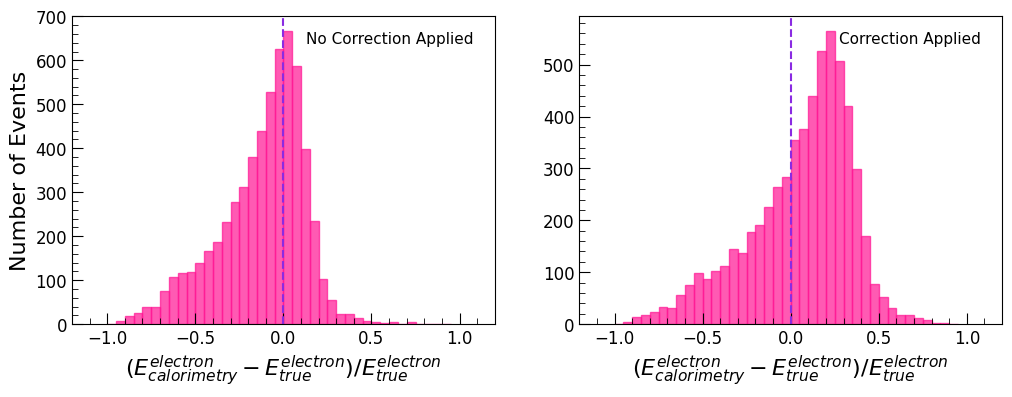

In [28]:
# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Calculate the difference between reconstructed energy and true energy (accuracy in resolution) 
energy_difference_uncorrected = signal_df['shr_energy_cali'] - signal_df['elec_e'] # Without correction
energy_difference_corrected = signal_df['shr_energy_cali'] / 0.83 - signal_df['elec_e'] # With correction

# Calculate (reconstructed energy - true energy) / true energy
relative_energy_difference_uncorrected = energy_difference_uncorrected / signal_df['elec_e']
relative_energy_difference_corrected = energy_difference_corrected / signal_df['elec_e']

# Plot the 1D histograms - more bins = lower frequency! BIN WIDTH NORMALISE!!!!!!!!!!! 
plotBins=np.arange(-1.0, 1.0, 0.05)
axs[0].hist(relative_energy_difference_uncorrected, bins=plotBins, color='deeppink', edgecolor='deeppink', alpha=0.7)
axs[1].hist(relative_energy_difference_corrected, bins=plotBins, color='deeppink', edgecolor='deeppink', alpha=0.7)

# Change the minimum and maximum x and y-axis values depending on how to plot comes out/what you want to see  
x_min = -1.2
x_max = 1.2
y_min = 0
y_max = 1200

# Set x and y axis labels and limits
for ax in axs:
    ax.set_xlabel((r'$(E^{electron}_{calorimetry} - E^{electron}_{true}) / E^{electron}_{true}$'), fontsize=16)
    ax.set_xlim(x_min, x_max)
    ax.minorticks_on()
    ax.tick_params(direction='in', which='both')
    ax.tick_params(axis='both', which='major', length=8)
    ax.tick_params(axis='both', which='minor', length=4)
    ax.tick_params(axis='both', labelsize=12)
    ax.axvline(x=0, color='blueviolet', linestyle='--')

    # ax.set_ylim(y_min, y_max)

axs[0].set_ylabel('Number of Events', fontsize=16)
                  
axs[0].text(0.95, 0.95, 'No Correction Applied', fontsize=11, ha='right', va='top', transform=axs[0].transAxes)
axs[1].text(0.95, 0.95, 'Correction Applied', fontsize=11, ha='right', va='top', transform=axs[1].transAxes)
                  
# Save the figure to my area
# plt.savefig('/uboone/app/users/abarnard/Relative_Energy_Resolution.png', bbox_inches='tight')
                  
plt.show()

Total number of events (no correction): 5969
Total number of events (with correction): 5960


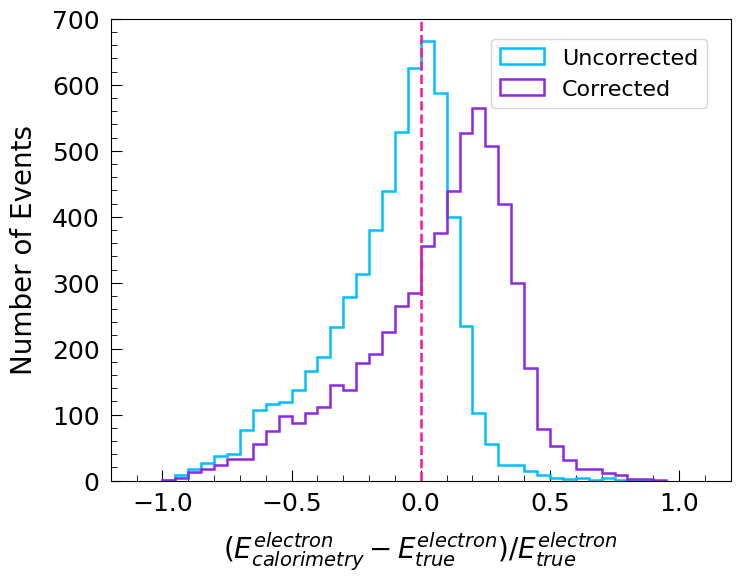

In [29]:
from matplotlib import rcParams, rcdefaults

# Restore default settings
rcdefaults()

# Calculate the difference between reconstructed energy and true energy (accuracy in resolution) 
energy_difference_uncorrected = signal_df['shr_energy_cali'] - signal_df['elec_e'] # Without correction
energy_difference_corrected = signal_df['shr_energy_cali'] / 0.83 - signal_df['elec_e'] # With correction

# Calculate (reconstructed energy - true energy) / true energy
relative_energy_difference_uncorrected = energy_difference_uncorrected / signal_df['elec_e']
relative_energy_difference_corrected = energy_difference_corrected / signal_df['elec_e']

# Calculate the histograms to get the counts
plotBins = np.arange(-1.0, 1.0, 0.05)
counts_uncorrected, _ = np.histogram(relative_energy_difference_uncorrected, bins=plotBins)
counts_corrected, _ = np.histogram(relative_energy_difference_corrected, bins=plotBins)

# Find the total number of events in each histogram
total_events_uncorrected = np.sum(counts_uncorrected)
total_events_corrected = np.sum(counts_corrected)

# Print the total number of events
print(f'Total number of events (no correction): {total_events_uncorrected}')
print(f'Total number of events (with correction): {total_events_corrected}')

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the histograms
plt.hist(relative_energy_difference_uncorrected, bins=plotBins, edgecolor='deepskyblue', histtype='step', linewidth=1.8, label='Uncorrected')
plt.hist(relative_energy_difference_corrected, bins=plotBins, edgecolor='blueviolet', histtype='step', linewidth=1.8, label='Corrected')

# Set x and y axis labels and limits
plt.xlabel((r'$(E^{electron}_{calorimetry} - E^{electron}_{true}) / E^{electron}_{true}$'), fontsize=20, labelpad=10)
plt.ylabel('Number of Events', fontsize=20, labelpad=10)
plt.xlim(-1.2, 1.2)
#plt.ylim(0, 900)
plt.axvline(x=0, color='deeppink', linestyle='--', linewidth=1.8)
plt.minorticks_on()
plt.tick_params(direction='in', which='both')
plt.tick_params(axis='both', which='major', length=8)
plt.tick_params(axis='both', which='minor', length=4)
plt.tick_params(axis='both', labelsize=18, pad=8)

# Add a legend with custom positioning
plt.legend(fontsize=16, loc='upper right', bbox_to_anchor=(0.98, 0.98))

# Save the figure to my area
# plt.savefig('/exp/uboone/app/users/abarnard/Relative_Energy_Resolution.pdf', bbox_inches='tight')

# Show the plot
# plt.show()

## Choose a variable! 

In [30]:
# xvar is defined earlier up in the code as something else (nu_e). To overwrite this change, you need to re-define it
# here, despite it being defined first in cfg.py! 
# Variables = "Opening Angle", "Proton Multiplicity", "Electron Energy", "Visible Energy"
name_of_variable = "X" 
xvar, true_var, bins, xlow, xhigh, x_label, x_ticks = get_variable_info(name_of_variable, ISRUN3, cut_level) # Order dependent! 

From cfg.py...
Variable definition: X
Reconstructed variable = tksh_angle
True variable = opening_angle
Bins = [-1.0, 1.0]
Lowest x-value on plot = -1.0
Highest x-value on plot = 1.0
x-axis title = Total Cross Section
x-axis labels = [-1.0, 1.0]


In [31]:
beamon_pot = parameters(ISRUN3)['beamon_pot']

In [32]:
selected_signal_query

'is_signal==True and swtrig_pre==1 and nslice==1 and 10<=reco_nu_vtx_sce_x<=246 and -106<=reco_nu_vtx_sce_y<=106 and 10<=reco_nu_vtx_sce_z<=1026 and contained_fraction>0.9 and n_showers_contained==1 and n_tracks_contained>0 and trk_energy>0.04 and shr_score<0.3 and shrmoliereavg<15 and shr_tkfit_dedx_Y<7 and trkpid<0.35 and tksh_distance<12 and BDT_score>0.575'

## Reco vs. True Distribution

In [33]:
bincenters = 0.5*(np.array(bins[:-1]+[xhigh])[1:]+np.array(bins[:-1]+[xhigh])[:-1])

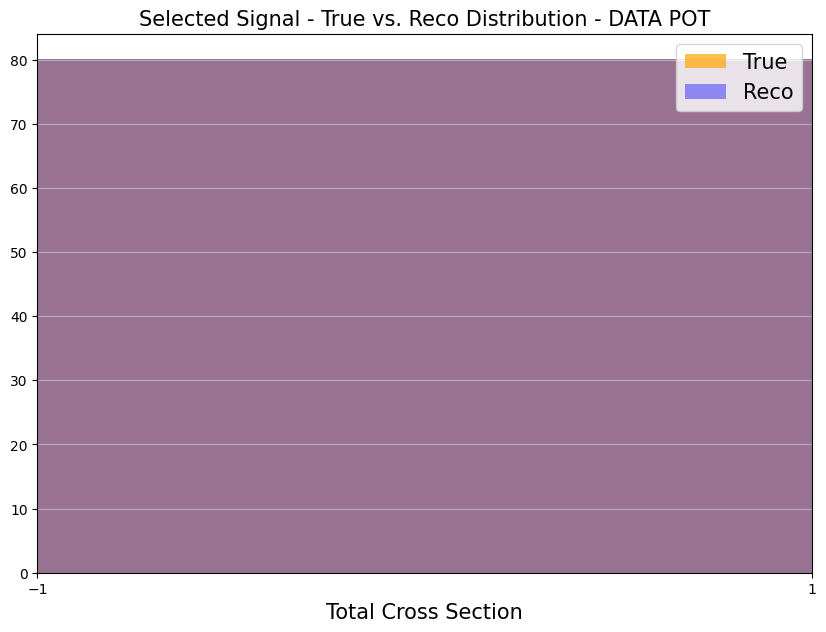

In [34]:
###### TRUE ######

fig = plt.figure(figsize=(10, 7))

plt.hist(signal_df.query(selected_signal_query)[true_var], bins, 
                weights=signal_df.query(selected_signal_query).totweight_intrinsic, 
                alpha=0.7, label='True', color='orange')


plt.xlabel(x_label, fontsize=15)
#plt.ylabel('$\\nu$ / '+str(intrinsic_pot) + ' POT', fontsize=15)
plt.legend(fontsize=15)
plt.ylim(0, 4000)
plt.title('Selected Signal - True Distribution - Intrinsic POT', fontsize=15)
plt.grid()
plt.close()

###### RECO ######

fig = plt.figure(figsize=(10, 7))

plt.hist(signal_df.query(selected_signal_query)[xvar], bins, 
                weights=signal_df.query(selected_signal_query).totweight_intrinsic, 
                alpha=0.4, label='Reco', color='blue')

plt.xlabel(x_label, fontsize=15)
#plt.ylabel('$\\nu$  / '+str(intrinsic_pot) + ' POT', fontsize=15)
plt.legend(fontsize=15)
plt.ylim(0, 4000)
plt.title('Selected Signal - Reco Distribution - Intrinsic POT', fontsize=15)
plt.grid()
plt.close()


###### TRUE VS. RECO ######

fig = plt.figure(figsize=(10, 7))

plt.hist(signal_df.query(selected_signal_query)[true_var], bins, 
                weights=signal_df.query(selected_signal_query).totweight_intrinsic, alpha=0.7, 
         label='True', color='orange')

plt.hist(signal_df.query(selected_signal_query)[xvar], bins, 
                weights=signal_df.query(selected_signal_query).totweight_intrinsic, alpha=0.4, 
         label='Reco', color='blue')

plt.xlabel(x_label, fontsize=15)
#plt.ylabel('$\\nu$  / '+str(intrinsic_pot) + ' POT', fontsize=15)
plt.legend(fontsize=15)
plt.xlim(xlow,xhigh)
plt.ylim(0, 4000)
plt.title('Selected Signal - True vs. Reco Distribution - Intrinsic POT', fontsize=15)
plt.grid()
plt.close()

###### TRUE VS. RECO - DATA NORMALIZED ######

fig = plt.figure(figsize=(10, 7))

true_selected = plt.hist(signal_df.query(selected_signal_query)[true_var], bins, 
                weights=signal_df.query(selected_signal_query).totweight_data, alpha=0.7, 
         label='True', color='orange')

reco_selected = plt.hist(signal_df.query(selected_signal_query)[xvar], bins, 
                weights=signal_df.query(selected_signal_query).totweight_data, alpha=0.4, 
         label='Reco', color='blue')

plt.xlabel(x_label, fontsize=15)
plt.xticks(x_ticks)
#plt.ylabel('$\\nu$  / '+str(data_pot), fontsize=15)
plt.legend(fontsize=15)
plt.title('Selected Signal - True vs. Reco Distribution - DATA POT', fontsize=15)
plt.grid()
plt.xlim(xlow,xhigh)
plt.show()


In [35]:
###### TRUE VS. RECO GENERATED - DATA NORMALIZED ######

true_generated = generated_signal(ISRUN3, true_var, bins, xlow, bins[-1])[0]
true_generated_sumw2 = generated_signal(ISRUN3, true_var, bins, xlow, bins[-1])[2]

reco_generated = generated_signal(ISRUN3, xvar, bins, xlow, bins[-1])[0]


Adding pot_scale column using dirt & EXT tune....
Adding pot_scale column using dirt & EXT tune....
Adding pot_scale column using dirt & EXT tune....


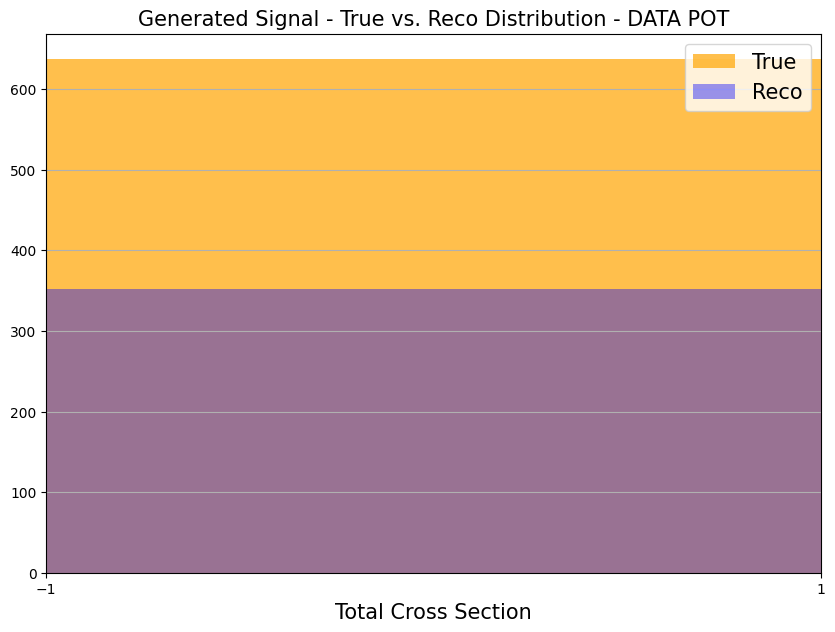

In [36]:
fig = plt.figure(figsize=(10, 7))

plt.hist(bincenters, bins, weights=true_generated, alpha=0.7, label='True', color='orange')
plt.hist(bincenters, bins, weights=reco_generated, alpha=0.4, label='Reco', color='blue')

plt.xticks(x_ticks)
plt.xlabel(x_label, fontsize=15)
plt.xlim(xlow,xhigh)
#plt.ylabel('$\\nu$  / '+str(data_pot), fontsize=15)
plt.legend(fontsize=15)
plt.title('Generated Signal - True vs. Reco Distribution - DATA POT', fontsize=15)
plt.grid()
plt.show()

## Construct response matrix

true selected:
[80.06741574]
80.06741574338739
reco selected: 
[80.06741574]
80.06741574338739


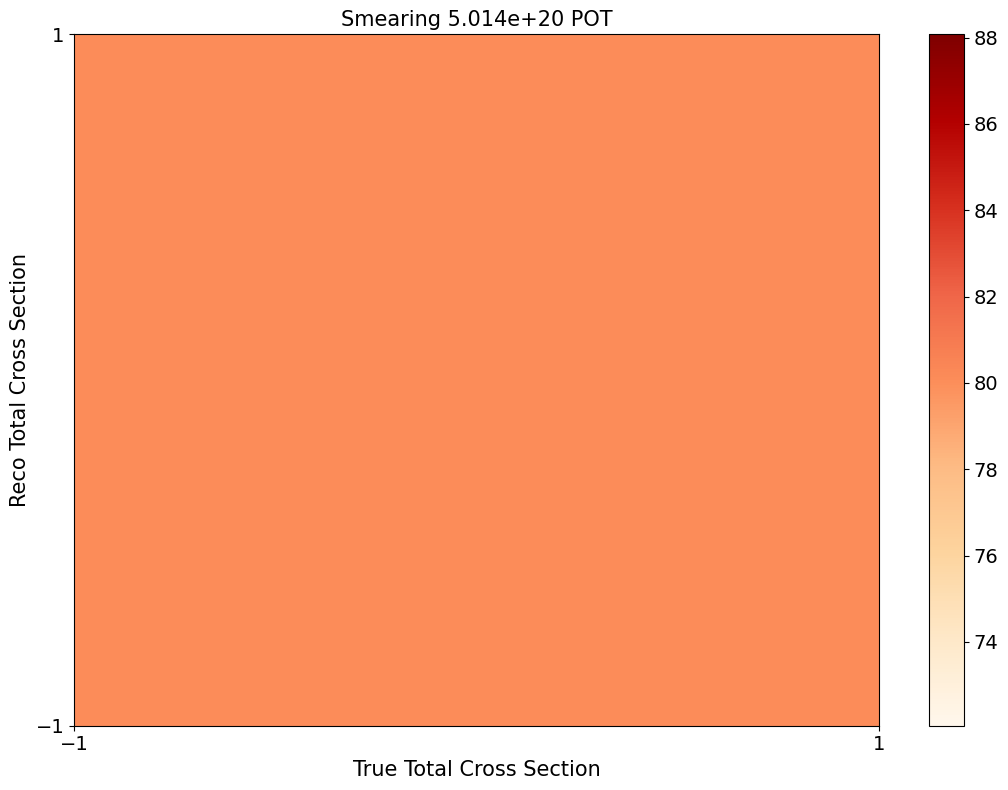

Adding pot_scale column using dirt & EXT tune....


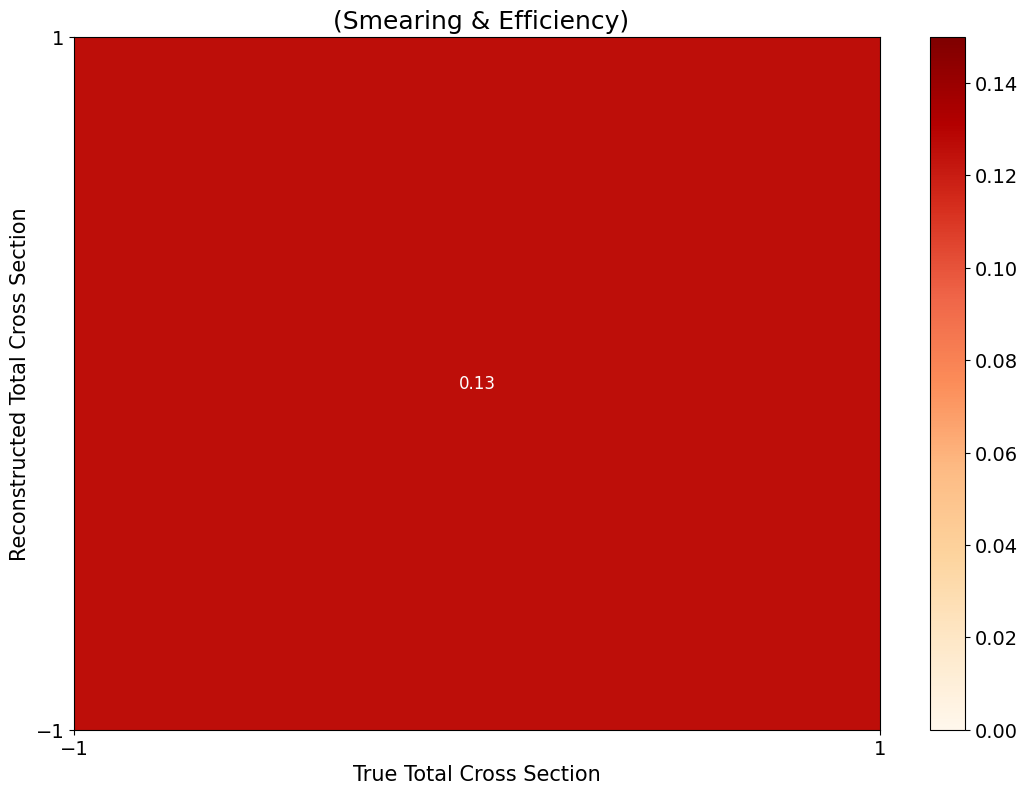

In [37]:
smear_dict = smear_matrix(true_var, xvar, bins, xlow, xhigh, ISRUN3, signal_df.query(selected_signal_query),
                          zmax=10, lbl=x_label, plot=True, eff=True, x_ticks=x_ticks)

In [38]:
###### check that R * true_generated = reco_selected

# clear away NaNs
smear_eff_array = np.array(smear_dict['smear_eff_array'])
smear_eff_array[np.isnan(smear_eff_array)] = 0

# matmul does row multiplication, so need to transpose
np.round( np.matmul(smear_eff_array.T, smear_dict['true_generated_counts']), 8) == np.round(reco_selected[0],8)

array([ True])

In [39]:
###### check that the sum of the rows == reco selected counts

smear_array = np.array(smear_dict['smear_array'])
smear_array[np.isnan(smear_array)] = 0

np.round( [np.nansum(x) for x in smear_array.T] , 8) == np.round(reco_selected[0],8)

array([ True])

In [40]:
###### check that the sum of the columns == true selected counts

smear_array = np.array(smear_dict['smear_array'])
smear_array[np.isnan(smear_array)] = 0

np.round( [np.nansum(x) for x in smear_array] , 8) == np.round(true_selected[0],8)

array([ True])

## efficiency - true neutrino energy [GeV]

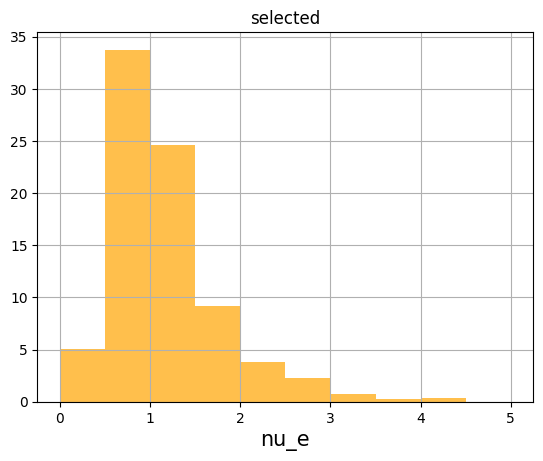

In [41]:
eff_true_selected, eff_bins, p = plt.hist(signal_df.query(selected_signal_query)['nu_e'], 10, range=[0, 5],
                weights=signal_df.query(selected_signal_query).totweight_data, 
                alpha=0.7,  color='orange')
plt.title('selected')
plt.xlabel('nu_e', fontsize=15)
#plt.ylim(0, 25)
plt.grid()
plt.show()

In [42]:
eff_true_generated = generated_signal(ISRUN3, 'nu_e', eff_bins, eff_bins[0], eff_bins[-1], weight='totweight_data')[0]
eff_true_generated_intrinsic = generated_signal(ISRUN3, 'nu_e', eff_bins, eff_bins[0], eff_bins[-1], weight='totweight_intrinsic')[0]


Adding pot_scale column using dirt & EXT tune....
Adding pot_scale column using dirt & EXT tune....


In [43]:
eff_bincenters  = 0.5*(eff_bins[1:]+eff_bins[:-1])

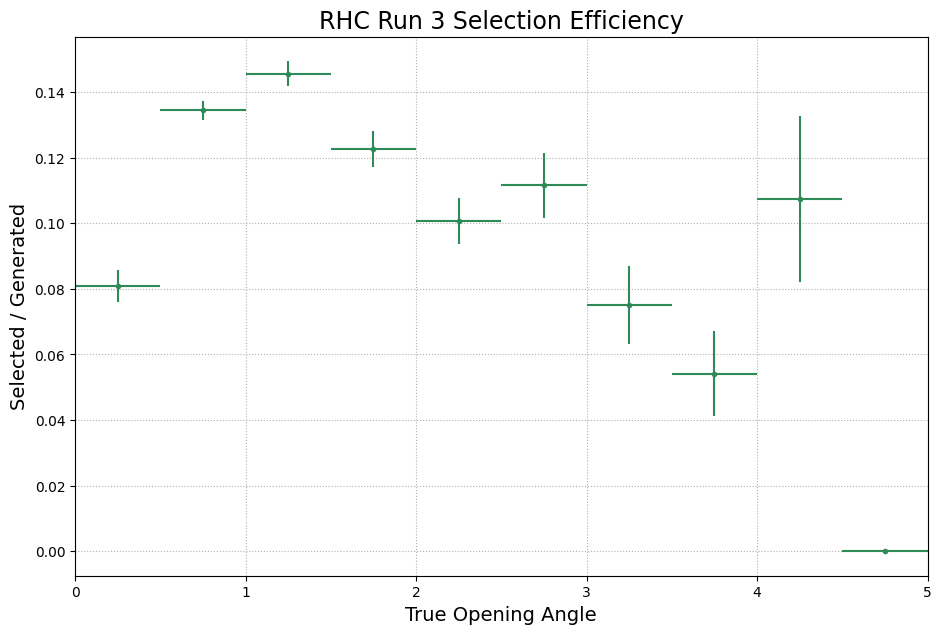

In [44]:
eff = [a/b for a,b in zip(eff_true_selected, eff_true_generated)]
eff_err = [ np.sqrt( (x*(1-x)) / y ) for x,y in zip(eff,eff_true_generated_intrinsic) ]

fig = plt.figure(figsize=(11, 7))  

plt.errorbar(eff_bincenters, eff, yerr=eff_err, 
             xerr=[0.25 for x in range(len(eff))],  
             fmt='.', color='seagreen')

#plt.yticks([0, .05, .1, .15, .2],fontsize=13)
#plt.ylim(0, .2)

plt.xlim(eff_bins[0], eff_bins[-1])

plt.xlabel("True Opening Angle", fontsize=14)
plt.ylabel("Selected / Generated", fontsize=14)


plt.grid(linestyle=':')
if ISRUN3==False: 
    plt.title("FHC Run 1 Selection Efficiency", fontsize=17)
    #plt.savefig(parameters(ISRUN3)['plots_path']+"fhc_eff_nue.pdf", transparent=True, bbox_inches='tight') 
    
elif ISRUN3==True: 
    plt.title("RHC Run 3 Selection Efficiency", fontsize=17)
    #plt.savefig(parameters(ISRUN3)['plots_path']+"rhc_eff_nue.pdf", transparent=True, bbox_inches='tight') 

plt.show()

## Save to new unfolding file 

In [45]:
smearing_dict = {
        'true_generated' :  true_generated, # true generated 
        'true_selected' : true_selected[0].tolist(), 
        'reco_generated' : reco_generated, 
        'reco_selected' : reco_selected[0].tolist(), # reco selected
        'smearing_matrix' : smear_array.tolist() # not normalized 
    }

In [46]:
import os
import json
from datetime import date

In [47]:
save = True  # Set to False if you don't want to save files

if not ISRUN3:
    file_path = 'unfolding/smearing/FHC_' + xvar + "_" + date.today().strftime("%m%d%y") + "_Total_Cross_Section.json"
else:
    file_path = 'unfolding/smearing/RHC_' + xvar + "_" + date.today().strftime("%m%d%y") + "_Total_Cross_Section.json"

if save:
    # Check if the file already exists
    if os.path.exists(file_path):
        print("File exists and is readable, need to update file name to save!")
    else:
        # Save the smearing_dict to the specified path and filename
        with open(file_path, 'w') as f:
            json.dump(smearing_dict, f)
else:
    print("Save is disabled. Skipping file write.")

# EXTRA/OUTDATED

In [48]:
# generated true signal distribution 

htrue_signal = TH1F("htrue_signal", "Generated MC Signal vs. True "+x_label+" ("+true_var+")", len(bins)-1, np.array(bins))

for i in range(len(bincenters)): 
    htrue_signal.Fill(bincenters[i], true_generated[i])


In [49]:
# selected reco signal distribution 
hreco = TH1D("hmeas", "Selected MC Signal vs. Reco "+x_label+" ("+xvar+")", len(bins)-1, np.array(bins))

for i in range(len(bincenters)): 
    hreco.Fill(bincenters[i], reco_selected[0][i])

In [50]:
# response matrix 
r = TH2D("hR", "Response Matrix", len(bins)-1, np.array(bins), len(bins)-1, np.array(bins))

In [51]:
for i in range(len(bincenters)): # i = column (x)
    for j in range(len(bincenters)): # j = row (y)
    
        w = smear_dict['smear_eff_array'][i][j] # [x][y]
        
        if np.isnan(w): 
            r.Fill(bincenters[i], bincenters[j], 0) 
            
        else: 
            r.Fill(bincenters[i], bincenters[j], w) 
            
        #print('x = '+str(i), 'y = '+str(j), 'counts = '+ str(w))

In [52]:
f = ROOT.TFile.Open("/exp/uboone/data/users/kmiller/uBNuMI_CCNp/unfolding/WSVD_"+xvar+"_RHCRUN3_TEST_JUNE22.root", "UPDATE")


OSError: Failed to open file /exp/uboone/data/users/kmiller/uBNuMI_CCNp/unfolding/WSVD_tksh_angle_RHCRUN3_TEST_JUNE22.root

SysError in <TFile::TFile>: file /exp/uboone/data/users/kmiller/uBNuMI_CCNp/unfolding/WSVD_tksh_angle_RHCRUN3_TEST_JUNE22.root can not be opened No such file or directory


In [ ]:
htrue_signal.Write()
hreco.Write()
r.Write()

In [ ]:
f.Close()

In [ ]:
# distribution of selected signal events across opening angle 

fig = plt.figure(figsize=(8, 5))

sel = plt.hist(fhc_sel.query(signal)['opening_angle'], 20, color='orange', range=[-1, 1])

plt.xlabel("cos $\\theta$", fontsize=15)
plt.ylabel("# of selected signal events", fontsize=15)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title("Signal: PDG==12, CC, N>0 protons, 0 pions, Op.Angle < +/-0.8\nLinear Selection w/o tksh_angle Cut ", fontsize=14)

plt.show()

In [ ]:
# efficiency across opening angle (current linear selection)

eff = [x/y for x, y in zip(sel[0], gen[0])]
eff_err = [ np.sqrt( (eff[i]*(1-eff[i]))/gen[0][i] ) for i in range(len(eff))]

bincenters = 0.5*(gen[1][1:]+gen[1][:-1])
binwidth = [abs(gen[1][1]-gen[1][0])/2 for x in range(len(bincenters))]

fig = plt.figure(figsize=(8, 5))

plt.errorbar(bincenters, eff, xerr=binwidth, yerr=eff_err, fmt='o', color='seagreen', ecolor='seagreen', markersize=3) 

plt.xlabel("cos $\\theta$", fontsize=15)
plt.ylabel("Efficiency", fontsize=15)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.ylim(0, 0.25)

plt.title("Signal: PDG==12, CC, N>0 protons, 0 pions\nLinear Selection with tksh_angle Cut ", fontsize=14)
plt.grid(linestyle=':')
plt.show()



In [ ]:
# efficiency across opening angle (lin sel without tksh_angle cut)


eff = [x/y for x, y in zip(sel[0], gen[0])]
eff_err = [ np.sqrt( (eff[i]*(1-eff[i]))/gen[0][i] ) for i in range(len(eff))]

bincenters = 0.5*(gen[1][1:]+gen[1][:-1])
binwidth = [abs(gen[1][1]-gen[1][0])/2 for x in range(len(bincenters))]

fig = plt.figure(figsize=(8, 5))

plt.errorbar(bincenters, eff, xerr=binwidth, yerr=eff_err, fmt='o', color='seagreen', ecolor='seagreen', markersize=3) 

plt.xlabel("cos $\\theta$", fontsize=15)
plt.ylabel("Efficiency", fontsize=15)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.ylim(0, 0.25)

plt.title("Signal: PDG==12, CC, N>0 protons, 0 pions, \nLinear Selection w/o tksh_angle Cut ", fontsize=14)
plt.grid(linestyle=':')
plt.show()

In [ ]:
# efficiency across opening angle (lin sel without tksh_angle cut & modified signal def )


# efficiency across opening angle (lin sel without tksh_angle cut)


eff = [x/y for x, y in zip(sel[0], gen[0])]
eff_err = [ np.sqrt( (eff[i]*(1-eff[i]))/gen[0][i] ) for i in range(len(eff))]

bincenters = 0.5*(gen[1][1:]+gen[1][:-1])
binwidth = [abs(gen[1][1]-gen[1][0])/2 for x in range(len(bincenters))]

fig = plt.figure(figsize=(8, 5))

plt.errorbar(bincenters, eff, xerr=binwidth, yerr=eff_err, fmt='o', color='seagreen', ecolor='seagreen', markersize=3) 

plt.xlabel("cos $\\theta$", fontsize=15)
plt.ylabel("Efficiency", fontsize=15)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(-1, 1)
plt.ylim(0, 0.25)

plt.title("Signal: PDG==12, CC, N>0 protons, 0 pions, Op.Angle < +/-0.8\nLinear Selection w/o tksh_angle Cut ", fontsize=14)
plt.grid(linestyle=':')
plt.show()

### Opening Angle

In [ ]:
# compute the magnitude of all MC Particles
def mc_p(df):
    
    p_all = []
    for index, row in df.iterrows():
        p_row = []
        for i in range(len(row['mc_pdg'])): 
            p = math.sqrt( row['mc_px'][i]*row['mc_px'][i] + row['mc_py'][i]*row['mc_py'][i] + row['mc_pz'][i]*row['mc_pz'][i] )
            p_row.append(p)
        
        p_all.append( p_row )
    
    df['mc_p'] = p_all 
    
    return df 


In [ ]:
# now get the proton with the highest momentum 
# use this to construct the truth opening angle 

def tksh_angle_truth(df): 
    
    tksh_angle_truth = []
    for index, row in df.iterrows(): 

        proton_max_p = 0
        proton_max_p_idx = 0
    
        # for each index in the PDG list 
        for i in range(len(row['mc_pdg'])): 
        
            # check if it is a proton 
            if row['mc_pdg'][i]==2212: 
                # check if it is max
                if row['mc_p'][i]>proton_max_p: 
                    # if so, replace
                    proton_max_p = row['mc_p'][i] 
                    proton_max_p_idx = i 
                
        # now use the leading proton index to compute the opening angle 
        proton_p = [ row['mc_px'][i], row['mc_py'][i], row['mc_pz'][i] ]
    
        # and construct electron vector (should be norm'd already)
        elec_p = [ row['elec_px'], row['elec_py'], row['elec_pz'] ]
        elec_p_mag = np.sqrt((elec_p[0]*elec_p[0])+(elec_p[1]*elec_p[1])+(elec_p[2]*elec_p[2]))
    
        # opening angle 
        cos = np.dot(proton_p, elec_p) / (proton_max_p*elec_p_mag)
        if proton_max_p==0 or elec_p_mag==0: 
            tksh_angle_truth.append(np.nan)
        
        else: 
            tksh_angle_truth.append(cos)
            
    df['opening_angle'] = tksh_angle_truth 
    
    return df
 

In [ ]:
fhc_sel = mc_p(fhc_sel)
rhc_sel = mc_p(rhc_sel)

In [ ]:
fhc_sel = tksh_angle_truth(fhc_sel)
rhc_sel = tksh_angle_truth(rhc_sel)

In [ ]:
fhc_sel.query('opening_angle>1')['opening_angle']

In [ ]:
fhc_sel.query('opening_angle<-1')['opening_angle']

In [ ]:
plt.hist([fhc_sel.query(signal)['opening_angle'], fhc_sel.query(signal)['tksh_angle']], 5,
        histtype='step', label=['true', 'reco'], weights=[fhc_sel.query(signal)['totweight_proj'], 
                                                          fhc_sel.query(signal)['totweight_proj']])
plt.title('Opening Angle')
plt.xlabel('cos $\\theta$')
plt.ylabel('$\\nu$ \ 9.23E20 POT')
plt.legend()

#plt.savefig('/uboone/data/users/kmiller/searchingfornues_v33/v08_00_00_33/plots/fhc/opening_angle_wide.pdf', 
#         transparent=True, bbox_inches='tight')
plt.show()



### scattering angle 

In [ ]:
# construct the true scattering angle 

def true_scatangle(df): 
    # length of the neutrino momentum vector
    nu_p_length = np.sqrt((df['true_nu_px']*df['true_nu_px'] + df['true_nu_py']*df['true_nu_py'] + df['true_nu_pz']*df['true_nu_pz']))
    df['true_nu_pmag'] = nu_p_length

    # use the normalized neutrino & electron momentum vectors (both in det coordinates) to construct the angle
    df['true_scatangle'] = ((df['true_nu_px']/df['true_nu_pmag'])*df['elec_px'])+((df['true_nu_py']/df['true_nu_pmag'])*df['elec_py'])+((df['true_nu_pz']/df['true_nu_pmag'])*df['elec_pz'])
   
    return df

In [ ]:
# construct the reco scattering angle 

def reco_scatangle(df): 


    # step 1: construct the neutrino direction vector (interaction vertex - beam target) in detector coordinates
    NuMITargetPos = fromBeamtoDet(0, 0, 0, False)

    # neutrino direction vector - detector coordinates, reconstructed, normalized
    
    nuX = df['reco_nu_vtx_sce_x'] - NuMITargetPos[0]
    nuY = df['reco_nu_vtx_sce_y'] - NuMITargetPos[1]
    nuZ = df['reco_nu_vtx_sce_z'] - NuMITargetPos[2]

    nu_dir_mag = np.sqrt((nuX*nuX)+(nuY*nuY)+(nuZ*nuZ))


    # step 2: normalize the neutrino direction vector and the reco shower momentum vector 
    nuX = nuX/nu_dir_mag
    nuY = nuY/nu_dir_mag
    nuZ = nuZ/nu_dir_mag

    shr_px = df['shr_px']
    shr_py = df['shr_py']
    shr_pz = df['shr_pz']

    shr_p_mag = np.sqrt((shr_px*shr_px)+(shr_py*shr_py)+(shr_pz*shr_pz))

    shr_px = shr_px/shr_p_mag
    shr_py = shr_py/shr_p_mag
    shr_pz = shr_pz/shr_p_mag

    # step 3: take the dot product between them 

    df['reco_scatangle'] = ( (nuX*shr_px)+(nuY*shr_py)+(nuZ*shr_pz) )
    
    return df



In [ ]:
fhc_sel = true_scatangle(fhc_sel)
rhc_sel = true_scatangle(rhc_sel)

In [ ]:
fhc_sel = reco_scatangle(fhc_sel)
rhc_sel = reco_scatangle(rhc_sel)

In [ ]:
from matplotlib.colors import LogNorm

In [ ]:
# angle off the beamline - numi coordinates (degrees)

plt.figure(figsize=(8, 5))

plt.hist([fhc_infv['thbeam'], fhc_infv['phibeam']], 
          40, histtype='step', weights=[fhc_infv['totweight_proj'], fhc_infv['totweight_proj']], 
          label=['$\\theta$ (off beamline)', '$\\phi$ (XY plane)'])
plt.xlabel('Angle [deg]', fontsize=14)
plt.ylabel('$\\nu$ / 9.23E20 POT', fontsize=14)
plt.yscale("log")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('FHC events in FV (overlay only)', fontsize=14)
plt.legend(fontsize=13)
plt.savefig('/uboone/data/users/kmiller/searchingfornues_v33/v08_00_00_33/plots/fhc/thetavsphi.pdf', 
         transparent=True, bbox_inches='tight')
plt.show()

In [ ]:

plt.figure(figsize=(8, 6))

plt.hist2d(fhc_infv['nu_e'], fhc_infv['thbeam'], 
           40, cmin=0.0000001, range=[[0, 5], [0, 140]], weights=fhc_infv['totweight_proj'])#, norm=LogNorm())
plt.xlabel('true neutrino energy [GeV]', fontsize=14)
plt.ylabel('true angle off beamline [deg]', fontsize=14)
#plt.ylabel('$\\nu$ / 9.23E20 POT', fontsize=14)
#plt.yscale("log")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
cbar = plt.colorbar()
#cbar.set_label('$\\nu$ / 11.95E20 POT (RHC projected)', fontsize=14)
cbar.ax.tick_params(labelsize=14)
plt.title("FHC events in FV (overlay only)", fontsize=14)
#plt.savefig('/uboone/data/users/kmiller/searchingfornues_v33/v08_00_00_33/plots/rhc/rhc_infv2d.pdf', 
#           transparent=True, bbox_inches='tight')
plt.show()



plt.figure(figsize=(8, 6))

plt.hist2d(fhc_sel['nu_e'], fhc_sel['thbeam'], 
           40, cmin=0.0000001, range=[[0, 5], [0, 140]], weights=fhc_sel['totweight_proj'])
          #, norm=LogNorm())
plt.xlabel('true neutrino energy [GeV]', fontsize=14)
plt.ylabel('true angle off beamline [deg]', fontsize=14)
#plt.ylabel('$\\nu$ / 9.23E20 POT', fontsize=14)
#plt.yscale("log")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
plt.title("FHC selected events in FV (overlay only)", fontsize=14)
#cbar.set_label('$\\nu$ / 11.95E20 POT (RHC projected)', fontsize=14)
#plt.savefig('/uboone/data/users/kmiller/searchingfornues_v33/v08_00_00_33/plots/rhc/rhc_sel2d.pdf', 
#           transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
# distribution of selected signal 

plt.hist(fhc_sel.query(signal)['theta'], 10, range=[0, 3], histtype='step', color='orange')
plt.xlabel('cos($\\theta$)', fontsize=14)
plt.title("angle between incoming & outgoing leptons - what is this?")
plt.show()

In [ ]:
# smearing 1D

plt.hist([fhc_sel.query(signal)['true_scatangle'], fhc_sel.query(signal)['reco_scatangle']], 
         20, histtype='step', weights=[fhc_sel.query(signal)['totweight_proj'], 
                                      fhc_sel.query(signal)['totweight_proj']], 
        label=['true', 'reco'])
plt.xlabel('cos($\\theta$)', fontsize=14)
plt.legend(loc=2)
plt.title("angle between incoming & outgoing leptons")
#plt.savefig('/uboone/data/users/kmiller/searchingfornues_v33/v08_00_00_33/plots/fhc/fhc_scatangle.pdf', 
#           transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
# does this assume the neutrino is coming from BNB direction? 

plt.hist([fhc_sel.query(signal)['theta'], fhc_sel.query(signal)['shr_theta']],
         20, range=[0, 3], histtype='step', label=['true', 'reco'])
plt.xlabel('cos($\\theta$)', fontsize=14)
plt.title("angle between incoming & outgoing leptons")
plt.legend()
#plt.savefig('/uboone/data/users/kmiller/searchingfornues_v33/v08_00_00_33/plots/fhc/fhc_theta.pdf', 
#           transparent=True, bbox_inches='tight')
plt.show()

### smearing & binning

In [ ]:
#reco = 'n_tracks_contained'
#true = 'nproton'
#bins = [1, 2, 3, 7]

# total or leading? Uh oh  
#true = 'proton_e'
#reco = 'trk_energy' #trk_energy_tot ?? 
#bins = [ 0.04, 0.24, 0.44, 1.26 ]

#true = 'true_e_visible'
#reco = 'NeutrinoEnergy2'
#bins = [0.19, .4, .61, .82, 1.10, 1.45, 4]

reco = 'shr_energy_cali'
true = 'elec_e'
bins = [0.09, 0.35, 0.65, 1.05, 1.5, 3]

In [ ]:
save = True

In [ ]:
n, b, p = plt.hist([ selected.query(signal)[true], selected.query(nue_CCother)[true]], range=[0, 4],
                        stacked=True, color=['orange', 'limegreen'], label=['signal', 'nue CC other'])
plt.ylim(0, 6000)
plt.legend()
plt.show()

In [ ]:
# from here on out we only work with signal 
selected_signal = selected.query(signal)

In [ ]:
# detector resolution - FHC, RHC, BOTH 

#true_reco_res(true, reco, fhc_sel, 'fhc', 90, save)
#true_reco_res(true, reco, rhc_sel, 'rhc', 90, save)

true_reco_res(true, reco, selected_signal, 'both', 5000, save)

In [ ]:
# min reco selected
min(list(selected.query(signal)[reco]))

In [ ]:
# min true  selected
min(list(selected.query(signal)[true]))

In [ ]:
# smearing - FHC, RHC, BOTH 

#smear_matrix(true, reco, bins, fhc_sel, 'fhc', 55, 'electron energy [GeV]', save)
#smear_matrix(true, reco, bins, rhc_sel, 'rhc', 55, 'electron energy [GeV]', save)

smear_matrix(true, reco, bins, selected_signal, 'both', 2500, 'electron energy [GeV]', save)

In [ ]:
# efficiency - FHC & RHC 

#truth_and_eff(true, bins, fhc_infv, fhc_sel, 'fhc', 100, 'True Electron Energy [GeV]', save)
#truth_and_eff(true, bins, fhc_infv, fhc_sel, 'rhc', 100, 'True Electron Energy [GeV]', save)



In [ ]:
comb_truth_and_eff(true, bins, comb_infv, selected_signal, 'electron energy [GeV]', save)

In [ ]:
print('total events = '+str(sum(selected_signal['totweight_data'])))

### FHC or RHC

In [ ]:
true = 'elec_e'
reco = 'shr_energy_cali'

horn = 'fhc'

if horn=='fhc': 
    gen_df = fhc_infv.query(signal)
    sel_df = fhc_sel.query(signal)
    
elif horn=='rhc': 
    gen_df = rhc_infv.query(signal)
    sel_df = rhc_sel.query(signal)

# shr energy
bins = [0.09, .35, .65, 1.05, 1.5, 3]

# reco neutrino energy 
#bins = [ 0.19, .4, .61, .82, 1.03, 1.4, 2, 4 ]

# track mult
#bins = [1, 2, 3, 7]




In [ ]:
save = True

In [ ]:
true_reco_res(true, reco, sel_df, horn, 90, save)

In [ ]:
truth_and_eff(true, bins, gen_df, sel_df, horn, 100, 'Visible Energy [GeV]', save)

In [ ]:
smear_matrix(true, reco, bins, sel_df, horn, 35, 'neutrino energy [GeV]', save)


In [ ]:
# min reco  selected
min(list(sel_df[reco]))

In [ ]:
# min true  selected
min(list(sel_df[true]))

### FHC & RHC

In [ ]:
comb_sel = pd.concat([fhc_sel, rhc_sel], ignore_index=True)
comb_infv = pd.concat([fhc_infv, rhc_infv], ignore_index=True)

In [ ]:
df_sel = comb_sel.query(signal)
df_gen = comb_infv.query(signal)

In [ ]:
true = 'true_e_visible'
reco = 'NeutrinoEnergy2'


# shr energy
#bins = [0.09, .35, .65, 1.05, 1.5, 3]

# reco energy 
bins = [ 0.19, .4, .61, .82, 1.03, 1.4, 2, 4 ]

# track mult
#bins = [1, 2, 3, 7]

# hadron energy 
#bins = [.04, .23, .42, 1.3]




In [ ]:
save = True

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df_sel['true_e_visible'], 16, range=[0, 4],histtype='step', label='true visible energy', 
         color='limegreen', weights=df_sel['totweight_proj'])
plt.hist(df_sel['nu_e'], 16, range=[0, 4], histtype='step', label='true $\\nu$ energy', 
         color='blue', weights=df_sel['totweight_proj'])

plt.legend(fontsize=13)
plt.xlabel("True Energy [GeV]", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 175)
plt.ylabel("$\\nu$ / 2.12E21 POT", fontsize=14)
#plt.savefig("/uboone/data/users/kmiller/searchingfornues_v33/v08_00_00_33/plots/both/neutrino_visible_energy.pdf", 
#            transparent=True, bbox_inches='tight') 
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df_sel['true_e_visible'], 16, range=[0, 4],histtype='step', label='true visible energy', 
         color='limegreen', weights=df_sel['totweight_proj'])
plt.hist(df_sel['NeutrinoEnergy2']/1000, 16, range=[0, 4], histtype='step', 
         label='reco energy', 
         color='red', weights=df_sel['totweight_proj'])

plt.legend(fontsize=13)
plt.xlabel("True Energy [GeV]", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 175)
plt.ylabel("$\\nu$ / 2.12E21 POT", fontsize=14)
#plt.savefig("/uboone/data/users/kmiller/searchingfornues_v33/v08_00_00_33/plots/both/visible_reco_energy.pdf", 
#            transparent=True, bbox_inches='tight') 
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df_sel['nu_e'], 16, range=[0, 4],histtype='step', label='true $\\nu$ energy', 
         color='blue', weights=df_sel['totweight_proj'])
plt.hist(df_sel['NeutrinoEnergy2']/1000, 16, range=[0, 4], histtype='step', 
         label='reco energy', 
         color='red', weights=df_sel['totweight_proj'])

plt.legend(fontsize=13)
plt.xlabel("True Energy [GeV]", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 175)
plt.ylabel("$\\nu$ / 2.12E21 POT", fontsize=14)
#plt.savefig("/uboone/data/users/kmiller/searchingfornues_v33/v08_00_00_33/plots/both/neutrino_reco_energy.pdf", 
#            transparent=True, bbox_inches='tight') 
plt.show()

In [ ]:
true_reco_res(true, reco, df_sel, 'both', 325, save)

In [ ]:
# normalized to data POT, but made from overlay POT

smear_matrix(true, reco, bins, df_sel, 'both', 350, 'hadronic energy [GeV]', save)